# **Sentiment Analysis of Netflix's Squid Game Tweets**

To be a global leader in entertainment business, Netflix can make use of sentiment analysis using Long Short-Term Memory (LSTM), Simple Recurrent Neural Network (SimpleRNN), Gated Recurrent Units(GRU) and Bidirectional LSTM models to develop better insights about customer preferences thereby gaining competitive advantage and increase their brand value.

## Data Collection and Preparation

The data for this application was obtained from the Kaggle.com website. The primary information came from: https://www.kaggle.com/deepcontractor/squid-game-netflix-twitter-data
This dataset has over 80,000 Tweets and 12 columns

In [1]:
# Resolve data path (works in repo checkout and in Colab) - AUTO DETECT UPLOADED FILE (like 12 notebook)
import os, glob
import pandas as pd

candidates = [
    "../data/external/tweets_v8.csv",
    "data/external/tweets_v8.csv",
    "tweets_v8.csv",
    "/content/tweets_v8.csv",
    "dataset.csv",
    "/content/dataset.csv",
    "tweets_preprocessing.csv",
    "/content/tweets_preprocessing.csv",
    "../tweets_preprocessing.csv",
    "notebooks/dataset.csv",
    "notebooks/tweets_preprocessing.csv",
]
# add any csv in current and /content
candidates += glob.glob("*.csv")
candidates += glob.glob("/content/*.csv")
candidates += glob.glob("notebooks/*.csv")
candidates += glob.glob("/content/drive/MyDrive/*.csv")

seen=set(); uniq=[]
for c in candidates:
    if c not in seen:
        seen.add(c); uniq.append(c)

DATA_PATH=None
for p in uniq:
    if os.path.exists(p) and os.path.getsize(p)>0:
        try:
            head = pd.read_csv(p, nrows=2, encoding='utf-8', encoding_errors='ignore', on_bad_lines='skip', engine='python')
            if any(col in head.columns for col in ['text','clean_comment','clean_text']):
                DATA_PATH=p
                break
        except:
            continue
if DATA_PATH is None:
    for p in uniq:
        if os.path.exists(p) and os.path.getsize(p)>0:
            DATA_PATH=p
            break
# Colab upload fallback
if DATA_PATH is None:
    try:
        from google.colab import files
        print("No data file found. Please upload tweets_v8.csv / dataset.csv")
        uploaded = files.upload()
        if uploaded:
            DATA_PATH = list(uploaded.keys())[0]
    except:
        pass

if DATA_PATH is None or not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Data file not found. Tried: {uniq}. Upload tweets_v8.csv or dataset.csv to Files pane.")

print("Using data at:", DATA_PATH)
tmp = pd.read_csv(DATA_PATH, nrows=3, encoding='utf-8', encoding_errors='ignore', on_bad_lines='skip', engine='python')
print(f"Columns: {tmp.columns.tolist()}")
print(tmp.head(2).to_string())


Using data at: tweets_v8.csv
Columns: ['user_name', 'user_location', 'user_description', 'user_created', 'user_followers', 'user_friends', 'user_favourites', 'user_verified', 'date', 'text', 'source', 'is_retweet']
                    user_name  user_location                                                                                                                                                user_description               user_created  user_followers  user_friends  user_favourites  user_verified                       date                                                                                                                             text               source  is_retweet
0   the _ûndër-ratèd niggáh👊🏾            NaN  @ManUtd die hard❤️❤️💪🏿💪🏿\n\n\nYOLO\n\n\nJ'ai besoin de quelqu'un qui peut m'aimer au pire🤗\nNon, je ne suis pas parfait, mais j'espère que tu vois ma valeur🤞🏾  2019-09-06 19:24:57+00:00             581          1035             8922          False  2021-10

In [2]:
#Importing all necessary packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.probability import FreqDist
from nltk.stem import WordNetLemmatizer
from nltk import FreqDist, regexp_tokenize
import string
import re
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import numpy as np
from matplotlib import cm
from sklearn.model_selection import train_test_split, cross_validate, KFold, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, TfidfTransformer
#import necessary keras packages
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, GRU, SimpleRNN
from tensorflow.keras.layers import Dropout, Activation, Bidirectional, GlobalMaxPool1D, SpatialDropout1D, TimeDistributed
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras import initializers, regularizers, constraints, optimizers, layers
from tensorflow.keras.preprocessing import text, sequence
import pickle

In [3]:
# ================= COLAB GPU SETUP (Added Fix) =================
# In Colab: Runtime -> Change runtime type -> T4 GPU -> Save
import tensorflow as tf
print(f"TensorFlow {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs available: {gpus}")
if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except: pass
    print(f"Using GPU: {gpus[0]}")
else:
    print("⚠️ No GPU detected! In Colab: Runtime -> Change runtime type -> GPU")
    print("Training will be very slow on CPU - GRU/LSTM benefit greatly from GPU")

# Verify NLTK & other deps
import nltk
try:
    nltk.data.find('tokenizers/punkt')
    print("NLTK punkt already present")
except LookupError:
    nltk.download('punkt', quiet=True)
    nltk.download('punkt_tab', quiet=True)
    print("Downloaded NLTK punkt")
try:
    import wordcloud
    print("wordcloud available")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "wordcloud"])
    print("Installed wordcloud")


TensorFlow 2.20.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Using GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
Downloaded NLTK punkt
wordcloud available


In [4]:
# Data Preparation - robust for any uploaded file
data = pd.read_csv(DATA_PATH, encoding='utf-8', encoding_errors='ignore', on_bad_lines='skip', engine='python')
print(data.head(2).to_string())
print(f"Initial shape: {data.shape}, columns: {list(data.columns)}")
# Normalize text column name: dataset.csv uses clean_comment, tweets_v8.csv uses text
if 'clean_comment' in data.columns and 'text' not in data.columns:
    data.rename(columns={'clean_comment':'text'}, inplace=True)
    print("Renamed clean_comment -> text")
# Drop optional columns only if they exist
cols_to_drop = ["user_name","user_location","user_description","user_created","user_followers","user_friends","user_favourites","user_verified","date","source","is_retweet"]
existing_drop = [c for c in cols_to_drop if c in data.columns]
if existing_drop:
    data = data.drop(columns=existing_drop)
    print(f"Dropped columns: {existing_drop}")
if 'text' not in data.columns:
    raise KeyError(f"'text' column not found after loading {DATA_PATH}. Columns: {data.columns.tolist()}")
print(data.isnull().sum())
data = data.dropna(subset=['text'])
print("After dropna:")
print(data.isnull().sum())
print(f"After prep shape: {data.shape}")


                    user_name user_location                                                                                                                                                user_description               user_created  user_followers  user_friends  user_favourites  user_verified                       date                                                                                                                             text               source  is_retweet
0   the _ûndër-ratèd niggáh👊🏾           NaN  @ManUtd die hard❤️❤️💪🏿💪🏿\n\n\nYOLO\n\n\nJ'ai besoin de quelqu'un qui peut m'aimer au pire🤗\nNon, je ne suis pas parfait, mais j'espère que tu vois ma valeur🤞🏾  2019-09-06 19:24:57+00:00             581          1035             8922          False  2021-10-06 12:05:38+00:00  When life hits and the same time poverty strikes you\nGong Yoo : Lets play a game \n#SquidGame #Netflix https://t.co/Cx7ifmZ8cN  Twitter for Android       False
1  Best uncle on planet earth       

In [5]:
# filtering duplicates
duplicates = data[data['text'].duplicated()]

# Check if there are duplicates present in the dataset
if len(duplicates) > 0:
    # Dropping the duplicates
    data.drop_duplicates(subset='text', inplace=True)
    print(f"{len(duplicates)} duplicates dropped")
else:
    print("No duplicates found")
print(f"Shape after dedup: {data.shape}")


4838 duplicates dropped
Shape after dedup: (75181, 1)


In [6]:
# Cleaning the text data
nltk.download('stopwords', quiet=True)
stemmer = nltk.SnowballStemmer("english")
stopword=set(stopwords.words('english'))

def clean(text):
    text = str(text).lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    text = [word for word in text.split(' ') if word not in stopword]
    text=" ".join(text)
    text = [stemmer.stem(word) for word in text.split(' ')]
    text=" ".join(text)
    return text
data["text"] = data["text"].apply(clean)
print(data["text"].head(2).tolist())
print(f"Cleaned shape: {data.shape}")


<>:8: SyntaxWarning: invalid escape sequence '\['
<>:9: SyntaxWarning: invalid escape sequence '\S'
<>:13: SyntaxWarning: invalid escape sequence '\w'
<>:8: SyntaxWarning: invalid escape sequence '\['
<>:9: SyntaxWarning: invalid escape sequence '\S'
<>:13: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_4153/498156785.py:8: SyntaxWarning: invalid escape sequence '\['
  text = re.sub('\[.*?\]', '', text)
/tmp/ipykernel_4153/498156785.py:9: SyntaxWarning: invalid escape sequence '\S'
  text = re.sub('https?://\S+|www\.\S+', '', text)
/tmp/ipykernel_4153/498156785.py:13: SyntaxWarning: invalid escape sequence '\w'
  text = re.sub('\w*\d\w*', '', text)


['life hit time poverti strike yougong yoo  let play game squidgam netflix ', 'marbl episod squidgam  ruin 😭😭😭']
Cleaned shape: (75181, 1)


### Creation of Word Cloud

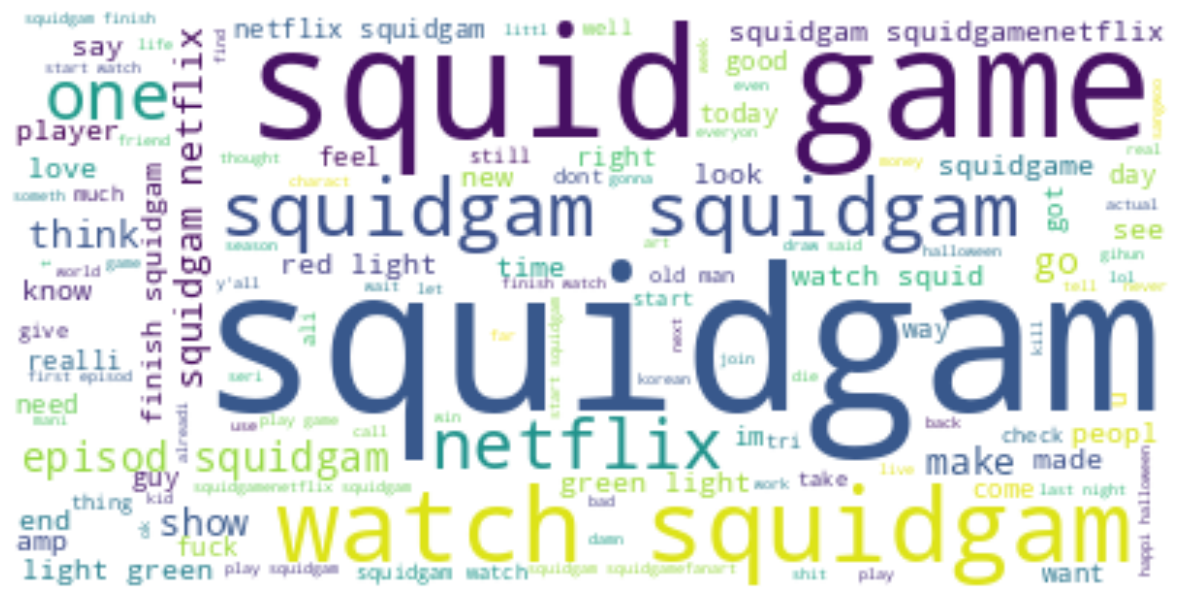

In [7]:
#Creating a word cloud based on the cleansed text
text = " ".join(i for i in data.text)
stopwords = set(STOPWORDS)
wordcloud = WordCloud(stopwords=stopwords, background_color="white").generate(text)
plt.figure( figsize=(15,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

### Polarity Scores for Input Tweets

In [8]:
#Find the sentiment polarity scores for text data using nltk
nltk.download('vader_lexicon')
sentiments = SentimentIntensityAnalyzer()
data["Sentiment_Polarity"] = [sentiments.polarity_scores(i)["compound"] for i in data["text"]]
print(data.head())

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


                                                text  Sentiment_Polarity
0  life hit time poverti strike yougong yoo  let ...              0.2263
1                    marbl episod squidgam  ruin 😭😭😭             -0.5859
2                                      squidgam time              0.0000
3  blood  slideim join squidgam thing im alreadi ...             -0.4767
4  two first game player kill mask guy  bloodi ni...             -0.8860


### Sentiment Identification based on the polarity scores

Threshold values are set for classifying sentences as either positive, neutral, or negative.

Threshold values are:

positive sentiment : (compound score >= 0.05)

neutral sentiment : (compound score > -0.05) and (compound score < 0.05)

negative sentiment : (compound score <= -0.05)


In [9]:
#Identify the emotion of the text based on the sentiment polarity scores
data['Emotion'] = np.where((data.Sentiment_Polarity >= 0.05), "Positive", np.where((data.Sentiment_Polarity <= -0.05), "Negative","Neutral"))
data.to_csv('Sentiment_Analysis_1.csv', index=False)
print(data.head(100))

                                                 text  Sentiment_Polarity  \
0   life hit time poverti strike yougong yoo  let ...              0.2263   
1                     marbl episod squidgam  ruin 😭😭😭             -0.5859   
2                                       squidgam time              0.0000   
3   blood  slideim join squidgam thing im alreadi ...             -0.4767   
4   two first game player kill mask guy  bloodi ni...             -0.8860   
..                                                ...                 ...   
95  contribut squidgam thing virgin hungri game co...              0.0000   
96  joohoney pull monsta xray tracksuit storage😆of...              0.0000   
97  guy squidgam 👏🏻👏🏻 definet bing watch act well ...              0.2732   
98         mannn blokkkkkoalasarecom huglif squidgam               0.0000   
99  give pollut red light give emissionfre blusmar...              0.0000   

     Emotion  
0   Positive  
1   Negative  
2    Neutral  
3   Negative  


In [10]:
data.shape

(75181, 3)

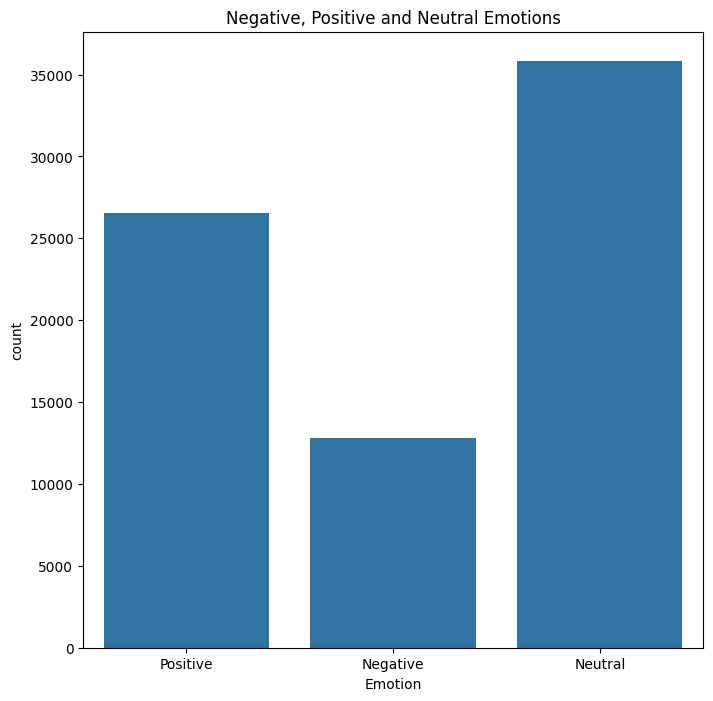

In [11]:
#counterplot of emotion
plt.figure(figsize=(8,8))
sns.countplot(x="Emotion", data=data)
plt.title('Negative, Positive and Neutral Emotions')
plt.show()


In [12]:
#differentiating three different emotions
print("Given Dataframe :\n", data)
data_negative = data[data['Emotion'] == 'Negative']
data_neutral = data[data['Emotion'] == 'Neutral']
data_positive = data[data['Emotion'] == 'Positive']

Given Dataframe :
                                                     text  Sentiment_Polarity  \
0      life hit time poverti strike yougong yoo  let ...              0.2263   
1                        marbl episod squidgam  ruin 😭😭😭             -0.5859   
2                                          squidgam time              0.0000   
3      blood  slideim join squidgam thing im alreadi ...             -0.4767   
4      two first game player kill mask guy  bloodi ni...             -0.8860   
...                                                  ...                 ...   
80014  yes yes yesarianagrandesquidgam  outerwear pro...              0.6597   
80015  squid game review revaaa squidgam review anyth...              0.0000   
80016  back amp forth squid game creator amp lebron j...              0.0000   
80017  sort game think theyll play inevit make squidg...              0.3400   
80018  venanciotaylor tracklist cala boca swifter gfv...              0.0000   

        Emotion  
0 

In [13]:
print(data_negative)
print(data_positive)
print(data_neutral)

                                                    text  Sentiment_Polarity  \
1                        marbl episod squidgam  ruin 😭😭😭             -0.5859   
3      blood  slideim join squidgam thing im alreadi ...             -0.4767   
4      two first game player kill mask guy  bloodi ni...             -0.8860   
6      bhundredhyun pls use gun 😩 baekhyun exo weareo...             -0.2732   
8      ive seen bilingu korean speaker slam squidgam ...             -0.3818   
...                                                  ...                 ...   
79949  netflix runaway hit seri squidgam show real pr...             -0.6369   
79950  watch squid game netflix tv seri remind movi s...             -0.2500   
79959  popular halloween costum year wrong answer onl...             -0.0772   
79968  theyr thingpoor peopl sign kill poor peopl ord...             -0.8979   
79977  bad feel run bogumssi run😱🐙🐙🐙hav watch squidga...             -0.5423   

        Emotion  
1      Negative  
3  

In [14]:
#tweet_text column
text_negative = data_negative['text']
text_neutral = data_neutral['text']
text_positive = data_positive['text']

In [15]:
# function to remove the non-words (must be defined BEFORE process_tweet)
import re
def remove_nonwords(string):
    return re.sub("[^A-Za-z ]\w*", ' ', string)

# function to process the tweets
def process_tweet(text):
    tw = remove_nonwords(text)
    tokens = nltk.word_tokenize(tw)
    from nltk.corpus import stopwords
    stopwords_list = list(stopwords.words('english'))
    stopwords_list = stopwords_list + list(string.punctuation)
    stopwords_list = stopwords_list + ["''", '""', '...', '``', '’', '“', '’', '”', '‘', '‘', 's', '2']
    stopwords_removed = [token.lower() for token in tokens if token.lower() not in stopwords_list]
    return stopwords_removed

print("Defined remove_nonwords and process_tweet (correct order)")


Defined remove_nonwords and process_tweet (correct order)


<>:4: SyntaxWarning: invalid escape sequence '\w'
<>:4: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_4153/2341153383.py:4: SyntaxWarning: invalid escape sequence '\w'
  return re.sub("[^A-Za-z ]\w*", ' ', string)


In [16]:
# (remove_nonwords already defined above - keeping this cell for backward compatibility)
# Verify functions exist
print(f"remove_nonwords test: {remove_nonwords('Hello 123 world!!!')[:30]}")
print(f"process_tweet test: {process_tweet('Hello world!!! This is a TEST 123')[:5]}")


remove_nonwords test: Hello   world   
process_tweet test: ['hello', 'world', 'test']


In [17]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)  # needed for newer NLTK word_tokenize
nltk.download('stopwords', quiet=True)
print("NLTK punkt/punkt_tab/stopwords downloaded")
# Now process tweets (text_negative etc already defined)
process_negative = list(map(process_tweet, text_negative))
process_neutral = list(map(process_tweet, text_neutral))
process_positive = list(map(process_tweet, text_positive))
print(f"Processed: neg={len(process_negative)}, neu={len(process_neutral)}, pos={len(process_positive)}")


NLTK punkt/punkt_tab/stopwords downloaded
Processed: neg=12784, neu=35828, pos=26569


In [18]:
print("Processed Negative tweets \n", text_negative, "\n")
print("Processed Positive tweets \n" ,text_positive, "\n")

print("Processed Neutral tweets \n" ,text_neutral, "\n")

Processed Negative tweets 
 1                          marbl episod squidgam  ruin 😭😭😭
3        blood  slideim join squidgam thing im alreadi ...
4        two first game player kill mask guy  bloodi ni...
6        bhundredhyun pls use gun 😩 baekhyun exo weareo...
8        ive seen bilingu korean speaker slam squidgam ...
                               ...                        
79949    netflix runaway hit seri squidgam show real pr...
79950    watch squid game netflix tv seri remind movi s...
79959    popular halloween costum year wrong answer onl...
79968    theyr thingpoor peopl sign kill poor peopl ord...
79977    bad feel run bogumssi run😱🐙🐙🐙hav watch squidga...
Name: text, Length: 12784, dtype: object 

Processed Positive tweets 
 0        life hit time poverti strike yougong yoo  let ...
7        pleas vote daili poll thank 😊do think donni va...
19              dalgona candi lover  newprofilep squidgam 
22       talk peopl love😂🤣🤣😂😂😂😂 save mysteri caus red l...
24       finish 

### Frequency Distribution of Tweets

In [19]:
flat_negative = [item for sublist in process_negative for item in sublist]
flat_neutral = [item for sublist in process_neutral for item in sublist]
flat_positive = [item for sublist in process_positive for item in sublist]

In [20]:
#frequency distribution of tweet
negative_freq = FreqDist(flat_negative)
neutral_freq = FreqDist(flat_neutral)
positive_freq = FreqDist(flat_positive)

In [21]:
#top 25 most common words in negative emotion
negative_freq.most_common(25)

[('squidgam', 9573),
 ('game', 2553),
 ('squid', 1687),
 ('watch', 1660),
 ('episod', 1258),
 ('fuck', 964),
 ('like', 718),
 ('show', 708),
 ('netflix', 671),
 ('get', 624),
 ('one', 620),
 ('die', 584),
 ('man', 573),
 ('shit', 553),
 ('peopl', 526),
 ('im', 513),
 ('finish', 512),
 ('end', 468),
 ('kill', 449),
 ('go', 442),
 ('got', 430),
 ('damn', 390),
 ('would', 389),
 ('think', 381),
 ('bad', 380)]

In [22]:
#top 25 most common words in Neutral emotion
neutral_freq.most_common(25)

[('squidgam', 26220),
 ('game', 7218),
 ('squid', 6221),
 ('watch', 4074),
 ('netflix', 3309),
 ('episod', 1990),
 ('squidgamenetflix', 1427),
 ('halloween', 1369),
 ('light', 1282),
 ('one', 1205),
 ('show', 1193),
 ('get', 1143),
 ('finish', 1121),
 ('go', 1004),
 ('new', 869),
 ('know', 836),
 ('red', 835),
 ('seri', 806),
 ('think', 781),
 ('squidgamefanart', 750),
 ('see', 728),
 ('time', 712),
 ('make', 685),
 ('first', 683),
 ('start', 683)]

In [23]:
#top 25 most common word in Positive emotion
positive_freq.most_common(25)

[('squidgam', 17251),
 ('game', 5102),
 ('squid', 3767),
 ('like', 3301),
 ('watch', 3168),
 ('project', 2451),
 ('play', 2421),
 ('netflix', 2322),
 ('good', 2131),
 ('love', 1611),
 ('show', 1496),
 ('episod', 1414),
 ('one', 1253),
 ('get', 1214),
 ('want', 1125),
 ('great', 1108),
 ('finish', 1107),
 ('best', 1085),
 ('hope', 1022),
 ('realli', 923),
 ('im', 911),
 ('go', 903),
 ('seri', 845),
 ('gogosquidgam', 845),
 ('light', 838)]

In [24]:
# create counts of negative, neutral and positive with values and words
negative_bar_counts = [x[1] for x in negative_freq.most_common(25)]
negative_bar_words = [x[0] for x in negative_freq.most_common(25)]

neutral_bar_counts = [x[1] for x in neutral_freq.most_common(25)]
neutral_bar_words = [x[0] for x in neutral_freq.most_common(25)]

positive_bar_counts = [x[1] for x in positive_freq.most_common(25)]
positive_bar_words = [x[0] for x in positive_freq.most_common(25)]

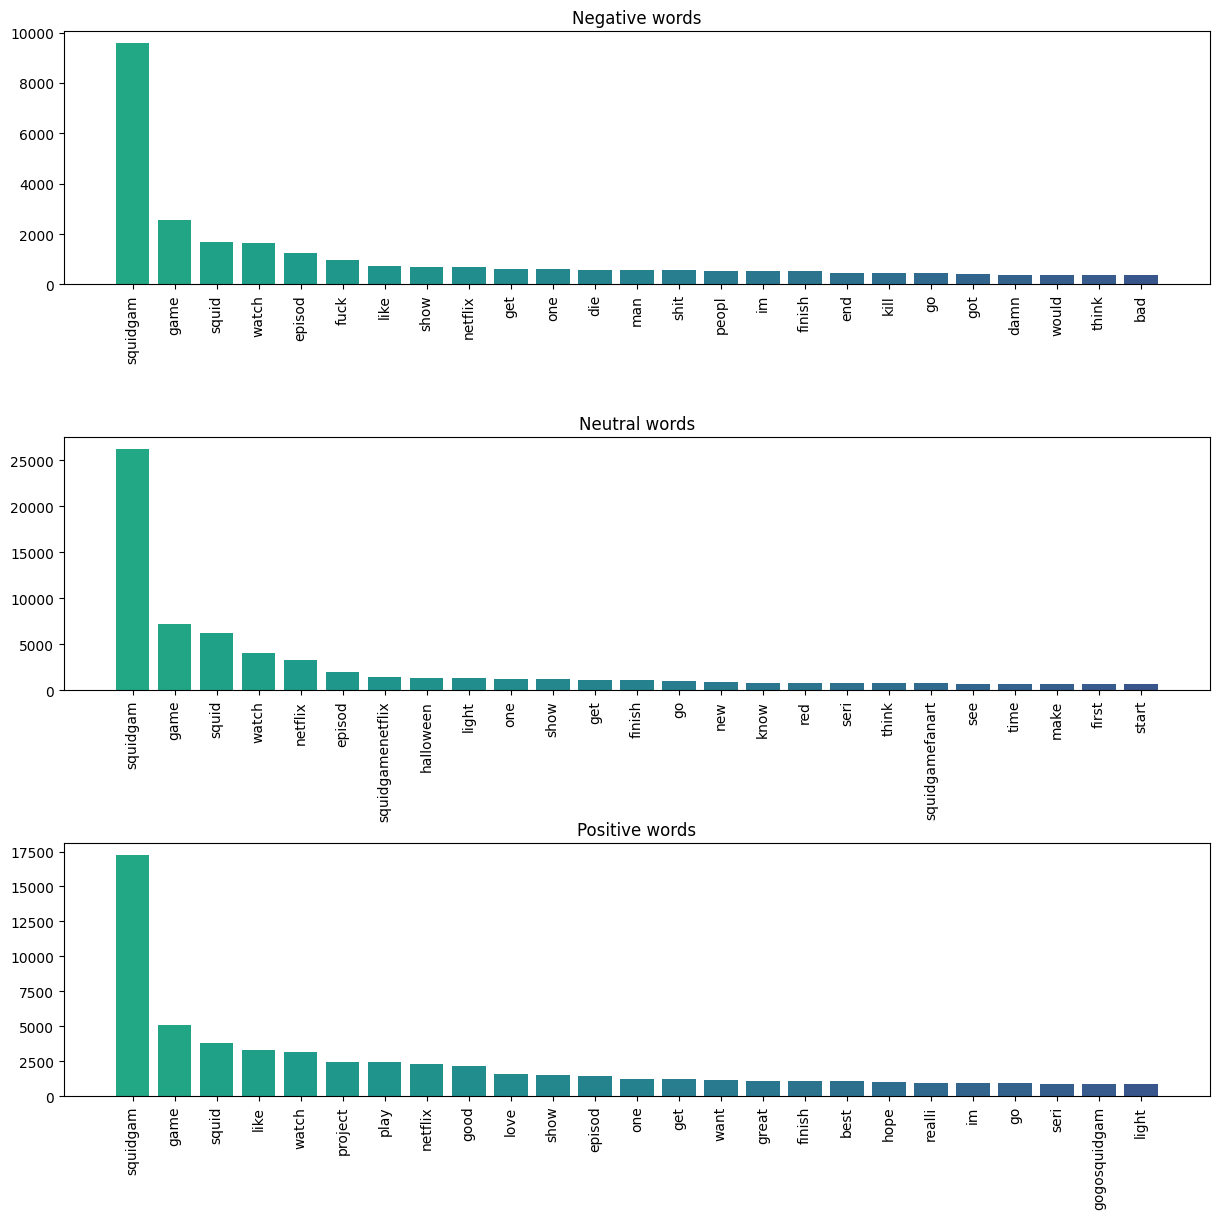

In [25]:
# Plotting negative, positive and neutral words from the tweets
new_figure = plt.figure(figsize=(12,12))
# set the color of our bar graphs
color = cm.viridis_r(np.linspace(.4,.8, 30))

ax = new_figure.add_subplot(311)
ax2 = new_figure.add_subplot(312)
ax3 = new_figure.add_subplot(313)

# Generate a line plot on first axes
ax.bar(negative_bar_words, negative_bar_counts, color= color)

# Draw a scatter plot on 2nd axes
ax2.bar(neutral_bar_words, neutral_bar_counts, color=color)

# Draw a scatter plot on 2nd axes
ax3.bar(positive_bar_words, positive_bar_counts, color=color)

ax.title.set_text('Negative words')
ax2.title.set_text('Neutral words')
ax3.title.set_text('Positive words')

for ax in new_figure.axes:
    plt.sca(ax)
    plt.xticks(rotation=90)

plt.tight_layout(pad=0)
plt.show()

### Creating Data Dictionary for Positive, Negative and Neutral Sentiments

In [26]:
#dictionary for negative, neutral and positive words
negative_dictionary = dict(zip(negative_bar_words, negative_bar_counts))
neutral_dictionary = dict(zip(neutral_bar_words, neutral_bar_counts))
positive_dictionary = dict(zip(positive_bar_words, positive_bar_counts))

In [27]:
# Creating the fuction wordcloud:
def generate_wordcloud(data):
    wordcloud = WordCloud(colormap='Spectral').generate_from_frequencies(data)
    plt.figure(figsize=(10,10),facecolor='k')
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

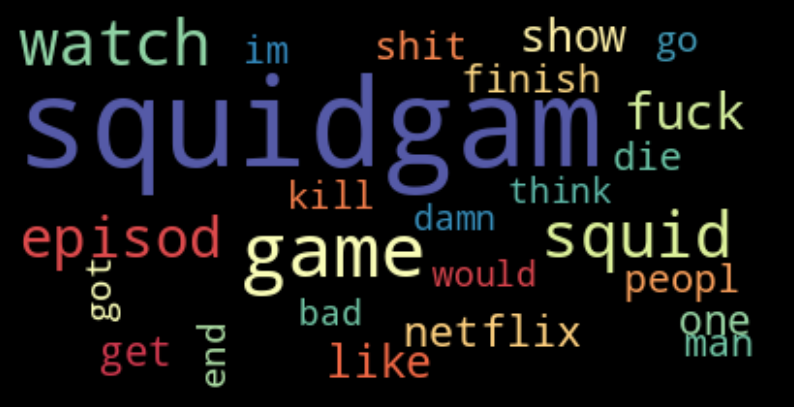

In [28]:
#Generating negative wordcloud
generate_wordcloud(negative_dictionary)

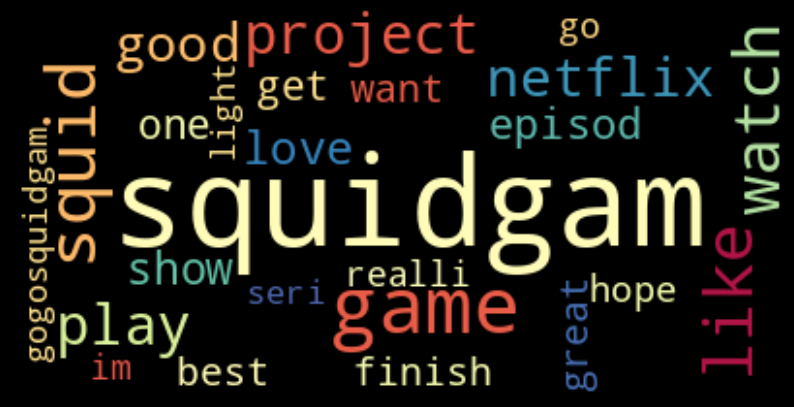

In [29]:
#generating positive wordcloud
generate_wordcloud(positive_dictionary)

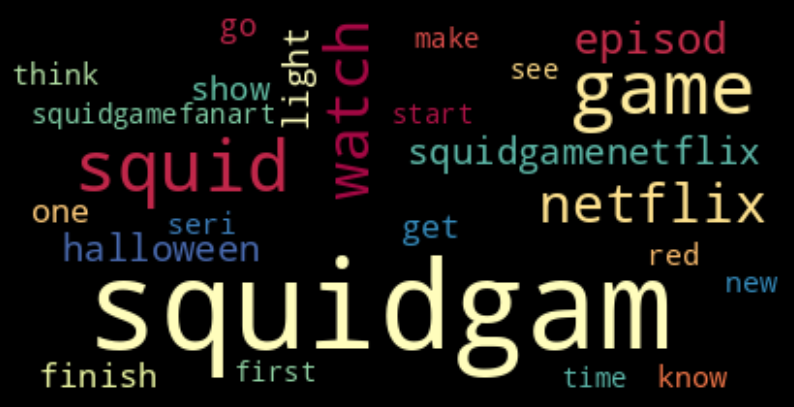

In [30]:
#generating neutral wordcloud
generate_wordcloud(neutral_dictionary)

## Model Creation

In [31]:
#initiate the variables
tweet_input = data['text']
target = data['Emotion']

In [32]:
# applying the function to our data/features
processed_data = list(map(process_tweet, tweet_input))

In [33]:
#indexing the processed data
pd.Series(processed_data)
processed_data[0]

['life',
 'hit',
 'time',
 'poverti',
 'strike',
 'yougong',
 'yoo',
 'let',
 'play',
 'game',
 'squidgam',
 'netflix']

Lemmatization

In [34]:
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('wordnet')
#lemmatization of text
lemmatized_output = []
lemmatizer = WordNetLemmatizer()
for lists in processed_data:
    lemmed = ' '.join([lemmatizer.lemmatize(w) for w in lists])
    lemmatized_output.append(lemmed)

[nltk_data] Downloading package wordnet to /root/nltk_data...


In [35]:
#lemmatized output
lemmatized_output[:10]

['life hit time poverti strike yougong yoo let play game squidgam netflix',
 'marbl episod squidgam ruin',
 'squidgam time',
 'blood slideim join squidgam thing im alreadi dead sugar honeycomb ofcsquidgame',
 'two first game player kill mask guy bloodi night third game kill',
 'thggo explod marketcap soonth world first mobathi game anoth levelkardiachain',
 'bhundredhyun pls use gun baekhyun exo weareoneexo squidgam',
 'plea vote daili poll thank think donni van de beek leav manchest unitedy',
 'ive seen bilingu korean speaker slam squidgam translat could feel qualiti write',
 'discov english audio episod squid game korean subtitl im use watch foreign fi']

In [36]:
#initiate X and y
X_lem = lemmatized_output
y_lem = target

In [37]:
# Implement train/test split of dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_lem, y_lem, test_size=0.20, random_state=42)

In [38]:
# Instantiate vectorizer object
tfidf = TfidfVectorizer()
# Fit the vectorizer
X_train_tf = tfidf.fit_transform(X_train)
X_test_tf = tfidf.transform(X_test)

In [39]:
from nltk import FreqDist, regexp_tokenize
# Pattern to capture words with apostrophes as one token
pattern = "([a-zA-Z]+(?:'[a-z]+)?)"

# Casting tweet_text to string or the tokenization doesn't work
data['text'] = data['text'].astype('str')

# Tokenizing tweets and inserting into data
data['raw_tokens'] = data['text'].map(lambda x: regexp_tokenize(x, pattern))

# Lowercase all tokens
data['raw_tokens'] = data['raw_tokens'].map(lambda x: [y.lower() for y in x])

In [40]:
#listing the stop words and creating a column in dataframe
from nltk.corpus import stopwords
stopwords_list = list(stopwords.words('english'))
stopwords_list = stopwords_list + list(string.punctuation)
stopwords_list = stopwords_list + ["''", '""', '...', '``', '’', '“', '’', '”', '‘', '‘', 's', '2']
data['raw_tokens_stopped'] = data['raw_tokens'].map(lambda x: [y for y in x if y not in stopwords_list])

In [41]:
#tokenize and pad the sequences (TensorFlow 2.x API)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences
tokenizer = Tokenizer(num_words=20000)
tokenizer.fit_on_texts(list(data['raw_tokens_stopped']))
list_tokenized = tokenizer.texts_to_sequences(data['raw_tokens_stopped'])
X_values = pad_sequences(list_tokenized, maxlen=100)

In [42]:
y_values= pd.get_dummies(target).values

In [43]:
# Implement train/test split of dataset
X_train_tk, X_test_tk,y_train_tk,y_test_tk = train_test_split(X_values,y_values,
                                                            test_size=0.20,
                                                            random_state=42)

In [44]:
X_train_tk.shape

(60144, 100)

In [45]:
y_train_tk.shape

(60144, 3)

In [46]:
y_train_tk

array([[False, False,  True],
       [False, False,  True],
       [False,  True, False],
       ...,
       [ True, False, False],
       [False,  True, False],
       [False,  True, False]])

In [47]:
with open('tokenizer.pickle', 'wb') as handle:
      pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

## RNN Model

In [48]:
import os
#architecture including an embedding layer, RNN layer
embedding_size = 128
model = Sequential()
n = 7120
model.add(Embedding(20000, embedding_size, input_length=100))
model.add(SimpleRNN(48))
model.add(Dropout(0.5))
model.add(Dense(50, activation='relu'))
#model.add(Dropout(0.5))
model.add(Dense(3, activation='softmax'))
print(model.summary())
#compiling the model
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])
#checking the summary of the model
model.summary()
#fitting the model on training data with epochs=4
history = model.fit(X_train_tk, y_train_tk, epochs=4, batch_size= 32, validation_split=0.2)
#evaluating the score for train and test data
train_score = model.evaluate(X_train_tk, y_train_tk)
test_score = model.evaluate(X_test_tk, y_test_tk)
print('Train score:', train_score)
print('Test Score:', test_score)
os.makedirs("models", exist_ok=True)
model.save("models/best_model_rnn.h5")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/4
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.8351 - loss: 0.4556 - val_accuracy: 0.9239 - val_loss: 0.2574
Epoch 2/4
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9401 - loss: 0.2027 - val_accuracy: 0.9218 - val_loss: 0.2531
Epoch 3/4
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.9508 - loss: 0.1653 - val_accuracy: 0.9076 - val_loss: 0.3464
Epoch 4/4
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9559 - loss: 0.1446 - val_accuracy: 0.9262 - val_loss: 0.2551
1880/1880 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9608 - loss: 0.1314
470/470 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9231 - loss: 0.2652


Train score: [0.1314486861228943, 0.9607940912246704]
Test Score: [0.26520854234695435, 0.9231229424476624]


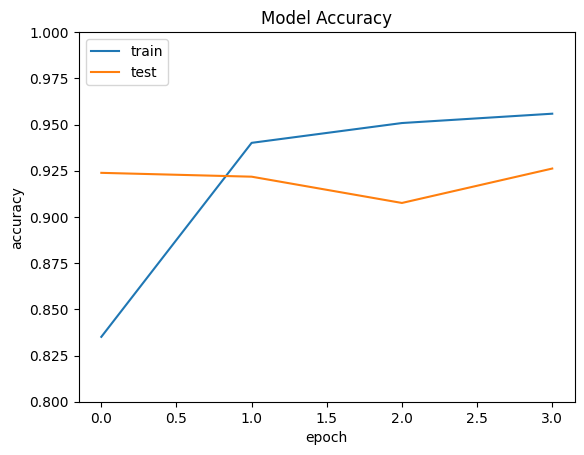

[0.4556121528148651, 0.2027052938938141, 0.1652792990207672, 0.14460952579975128]


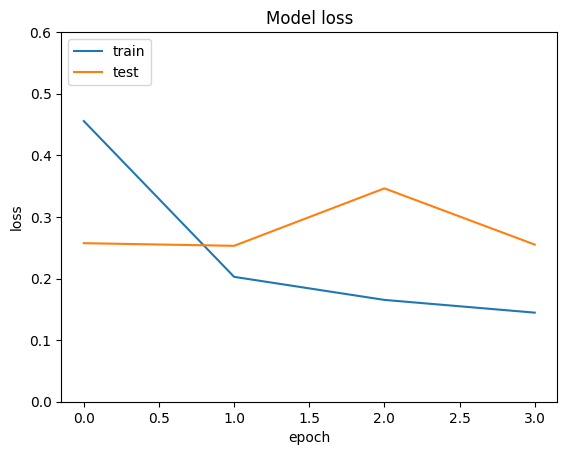

In [49]:
#plotting the Accuracy between training and test sets
#import matplotlib.pyplot as plt
plt.ylim(0.8,1.0)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

#plotting the loss between training and test sets
print(history.history['loss'])
plt.ylim(0,0.6)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

## GRU Model

In [50]:
import os
#architecture including an embedding layer, GRU layer
embedding_size = 128
model = Sequential()
n = 7120
model.add(Embedding(20000, embedding_size, input_length=100))
model.add(GRU(48))
model.add(Dropout(0.5))
model.add(Dense(50, activation='relu'))
#model.add(Dropout(0.5))
model.add(Dense(3, activation='softmax'))
print(model.summary())
#compiling the model
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])
#checking the summary of the model
model.summary()
#fitting the model on training data with epochs=4
history = model.fit(X_train_tk, y_train_tk, epochs=4, batch_size= 32, validation_split=0.2)
#evaluating the score for train and test data
train_score = model.evaluate(X_train_tk, y_train_tk)
test_score = model.evaluate(X_test_tk, y_test_tk)
print('Train score:', train_score)
print('Test Score:', test_score)
os.makedirs("models", exist_ok=True)
model.save("models/best_model_gru.h5")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

...

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/4
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.8772 - loss: 0.3549 - val_accuracy: 0.9383 - val_loss: 0.2062
Epoch 2/4
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9497 - loss: 0.1708 - val_accuracy: 0.9387 - val_loss: 0.2002
Epoch 3/4
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9592 - loss: 0.1344 - val_accuracy: 0.9386 - val_loss: 0.2131
Epoch 4/4
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9660 - loss: 0.1065 - val_accuracy: 0.9372 - val_loss: 0.2322
1880/1880 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9691 - loss: 0.1013
470/470 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9359 - loss: 0.2413


Train score: [0.10125447809696198, 0.9690576195716858]
Test Score: [0.2412790060043335, 0.9358914494514465]


470/470 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


<Axes: >

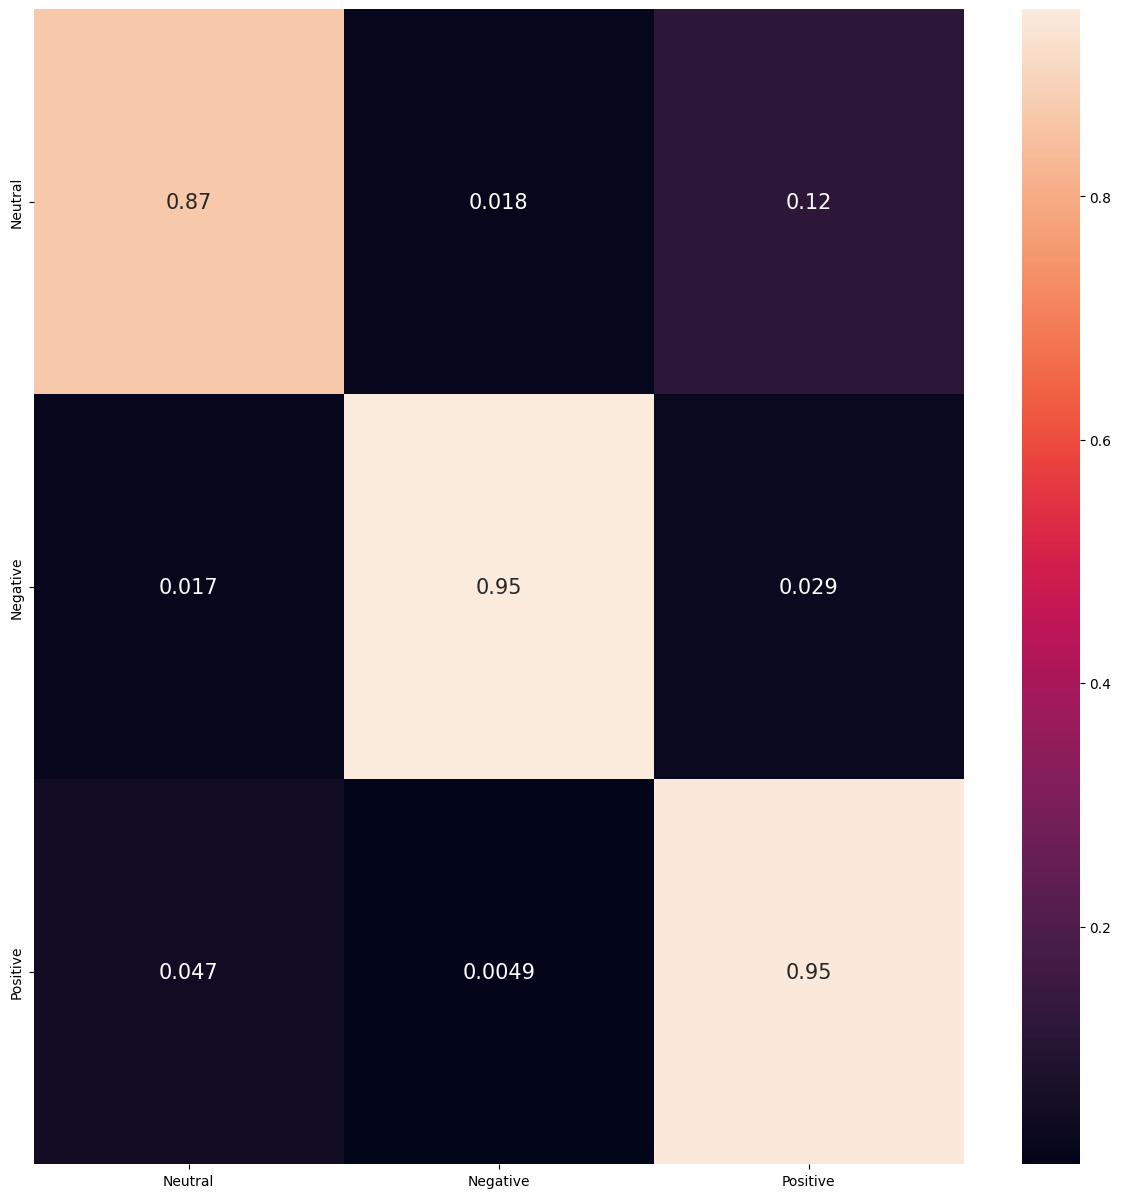

In [52]:
predictions = model.predict(X_test_tk)
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_test_tk.argmax(axis=1), np.around(predictions, decimals=0).argmax(axis=1))
import seaborn as sns
conf_matrix = pd.DataFrame(matrix, index = ['Neutral','Negative','Positive'],columns = ['Neutral','Negative','Positive'])
#Normalizing
conf_matrix = conf_matrix.astype('float') / conf_matrix.sum(axis=1).to_numpy()[:, np.newaxis]
plt.figure(figsize = (15,15))
sns.heatmap(conf_matrix, annot=True, annot_kws={"size": 15})

From the above’s confusion matrix, we can deduce that:


* 93% of positive texts were classified as positive.
* 96% of negative texts were classified as negative.
* 92% of neutral texts were classified as neutral.

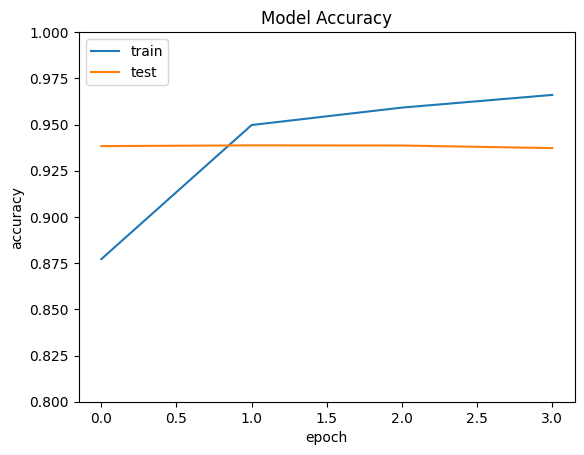

In [53]:
#plotting the Accuracy between training and test sets
#import matplotlib.pyplot as plt
plt.ylim(0.8,1.0)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

[0.35485124588012695, 0.17083106935024261, 0.13442811369895935, 0.10646737366914749]


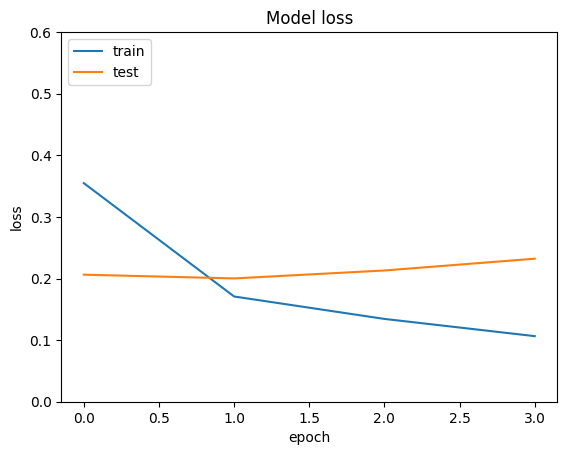

In [54]:
#plotting the loss between training and test sets
print(history.history['loss'])
plt.ylim(0,0.6)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

## LSTM Model

In [55]:
#architecture including an embedding layer, LSTM layer
embedding_size = 128
model = Sequential()
n = 7120
model.add(Embedding(20000, embedding_size, input_length=100))
model.add(LSTM(48, return_sequences=False))
model.add(Dropout(0.5))
model.add(Dense(50, activation='relu'))
#model.add(Dropout(0.5))
model.add(Dense(3, activation='softmax'))
print(model.summary())

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [57]:
#compiling the model
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])


In [58]:
#checking the summary of the model
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [59]:
#fitting the model on training data with epochs=4
history = model.fit(X_train_tk, y_train_tk, epochs=4, batch_size= 32, validation_split=0.2)

Epoch 1/4
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.8700 - loss: 0.3714 - val_accuracy: 0.9405 - val_loss: 0.2012
Epoch 2/4
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9514 - loss: 0.1689 - val_accuracy: 0.9390 - val_loss: 0.2024
Epoch 3/4
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9603 - loss: 0.1296 - val_accuracy: 0.9407 - val_loss: 0.2042
Epoch 4/4
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9670 - loss: 0.0986 - val_accuracy: 0.9404 - val_loss: 0.2280


In [60]:
#evaluating the score for train and test data
train_score = model.evaluate(X_train_tk, y_train_tk)
test_score = model.evaluate(X_test_tk, y_test_tk)
print('Train score:', train_score)
print('Test Score:', test_score)

1880/1880 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9694 - loss: 0.0978
470/470 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9413 - loss: 0.2294
Train score: [0.09777551889419556, 0.969356894493103]
Test Score: [0.22938421368598938, 0.941344678401947]


In [61]:
import os
os.makedirs("models", exist_ok=True)
model.save("models/best_model_lstm.h5")

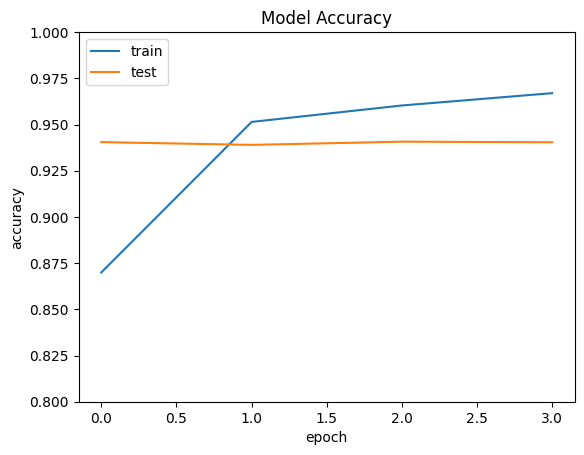

In [62]:
#plotting the Accuracy between training and test sets
#import matplotlib.pyplot as plt
plt.ylim(0.8,1.0)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

[0.37144601345062256, 0.16890954971313477, 0.12960520386695862, 0.09859161823987961]


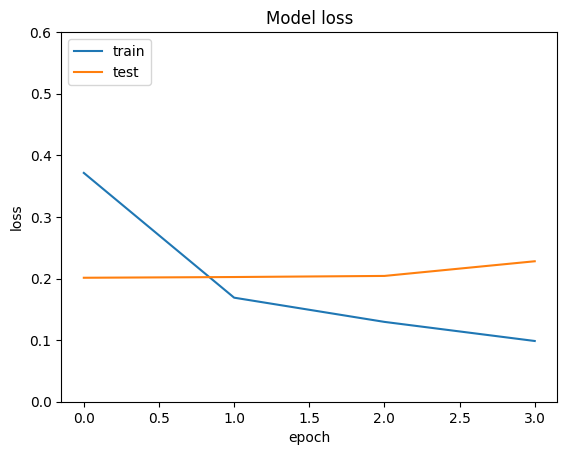

In [63]:
#plotting the loss between training and test sets
print(history.history['loss'])
plt.ylim(0,0.6)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

## Bidirectional LSTM

In [64]:
import os
#architecture including an embedding layer, Bidirectional LSTM layer
#architecture including an embedding layer, LSTM layer
embedding_size = 128
model = Sequential()
n = 7120
model.add(Embedding(20000, embedding_size, input_length=100))
model.add(Bidirectional(LSTM(48, return_sequences=False)))
model.add(Dropout(0.5))
model.add(Dense(50, activation='relu'))
#model.add(Dropout(0.5))
model.add(Dense(3, activation='softmax'))
print(model.summary())

#compiling the model
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])
#checking the summary of the model
model.summary()
#fitting the model on training data with epochs=4
history = model.fit(X_train_tk, y_train_tk, epochs=4, batch_size= 32, validation_split=0.2)
#evaluating the score for train and test data
train_score = model.evaluate(X_train_tk, y_train_tk)
test_score = model.evaluate(X_test_tk, y_test_tk)
print('Train score:', train_score)
print('Test Score:', test_score)
os.makedirs("models", exist_ok=True)
model.save("models/best_model_bi_lstm.h5")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

...

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/4
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - accuracy: 0.8710 - loss: 0.3697 - val_accuracy: 0.9417 - val_loss: 0.2058
Epoch 2/4
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.9513 - loss: 0.1718 - val_accuracy: 0.9389 - val_loss: 0.2068
Epoch 3/4
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 42s 15ms/step - accuracy: 0.9588 - loss: 0.1315 - val_accuracy: 0.9373 - val_loss: 0.2042
Epoch 4/4
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.9666 - loss: 0.1002 - val_accuracy: 0.9369 - val_loss: 0.2347
1880/1880 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9662 - loss: 0.1022
470/470 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9368 - loss: 0.2311


Train score: [0.10220920294523239, 0.9662144184112549]
Test Score: [0.23112645745277405, 0.9368225336074829]


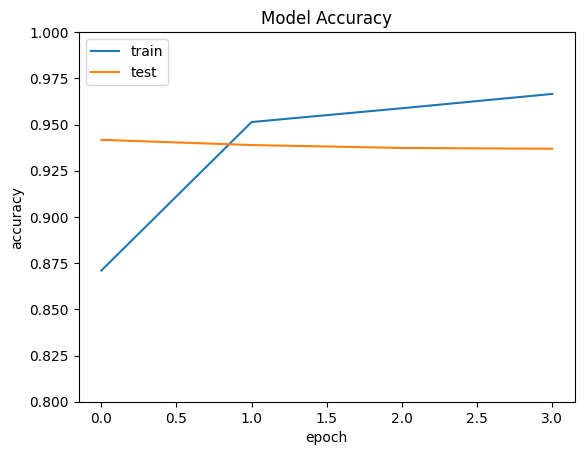

[0.36972886323928833, 0.1718166470527649, 0.1315338909626007, 0.10021139681339264]


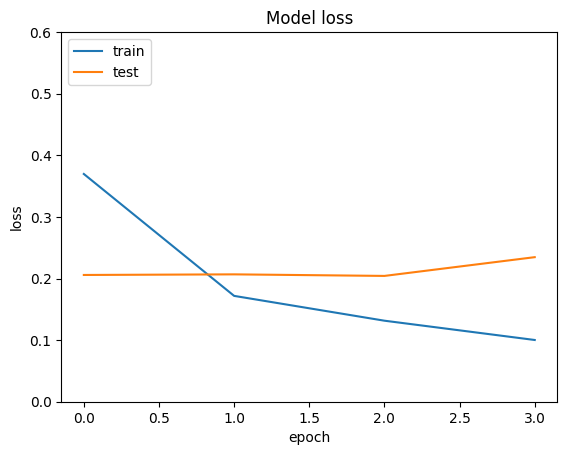

In [65]:
#plotting the Accuracy between training and test sets
#import matplotlib.pyplot as plt
plt.ylim(0.8,1.0)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

#plotting the loss between training and test sets
print(history.history['loss'])
plt.ylim(0,0.6)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

## Model Prediction

In [66]:
from tensorflow.keras.models import load_model
import pickle

# --- Load model and tokenizer correctly (fix previous bug) ---
# In Colab, ensure GPU is available for TensorFlow
import tensorflow as tf
print(f"TensorFlow {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPUs available: {gpus}")
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except: pass
else:
    print("No GPU found for TF - set Runtime -> Change runtime type -> GPU")

# Load tokenizer (saved during training) - DON'T create new Tokenizer per prediction
try:
    tokenizer = pickle.load(open('tokenizer.pickle','rb'))
    print("Loaded saved tokenizer.pickle")
    print(f"Tokenizer word_index size: {len(tokenizer.word_index)}")
except FileNotFoundError:
    print("tokenizer.pickle not found - creating from data (fallback)")
    from tensorflow.keras.preprocessing.text import Tokenizer
    tokenizer = Tokenizer(num_words=20000)
    tokenizer.fit_on_texts(data['text'].astype(str).tolist())
    print(f"Fitted tokenizer on {len(data)} texts")

try:
    model = load_model('models/best_model_gru.h5')
    print("Loaded models/best_model_gru.h5")
except:
    # Try alternative paths in Colab
    import glob
    candidates = glob.glob("**/best_model*.h5", recursive=True) + glob.glob("*.h5") + glob.glob("/content/*.h5")
    print(f"Model not found at models/best_model_gru.h5, candidates: {candidates}")
    raise

# Determine correct sentiment class order from training (pd.get_dummies sorts alphabetically)
# y_values = pd.get_dummies(target).values -> columns sorted: Negative, Neutral, Positive
# So index 0=Negative, 1=Neutral, 2=Positive
sentiment_classes = ['Negative', 'Neutral', 'Positive']
# If you used different order, check via: print(pd.get_dummies(data['Emotion']).columns.tolist())
print(f"Class mapping: {sentiment_classes} (from pd.get_dummies alphabetical)")

def predict_class(text):
    '''Function to predict sentiment class of the passed text - FIXED'''
    cleansed_text = clean(text)
    # Tokenize as SINGLE document (not list of characters!)
    seq = tokenizer.texts_to_sequences([cleansed_text])
    from tensorflow.keras.utils import pad_sequences
    X_values = pad_sequences(seq, maxlen=100)
    # Predict once
    pred = model.predict(X_values, verbose=0)
    pred_class_idx = pred.argmax(axis=1)[0]
    pred_label = sentiment_classes[pred_class_idx]
    print(f"Input: {text}")
    print(f"Cleansed: {cleansed_text}")
    print(f"Probas: {pred[0]}")
    print(f'The predicted sentiment is {pred_label} (idx {pred_class_idx})')
    return pred_label


TensorFlow 2.20.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Loaded saved tokenizer.pickle
Tokenizer word_index size: 50661


Loaded models/best_model_gru.h5
Class mapping: ['Negative', 'Neutral', 'Positive'] (from pd.get_dummies alphabetical)


In [67]:
predict_class("Must watch show best brilliant, fantastic ever ")

Input: Must watch show best brilliant, fantastic ever 
Cleansed: must watch show best brilliant fantast ever 
Probas: [0.00115302 0.00441536 0.9944317 ]
The predicted sentiment is Positive (idx 2)


'Positive'

In [68]:
predict_class("#SquidGame honestly sucks, not worth the hype. worse show ever")

Input: #SquidGame honestly sucks, not worth the hype. worse show ever
Cleansed: squidgam honest suck worth hype wors show ever
Probas: [0.02868425 0.0231323  0.9481834 ]
The predicted sentiment is Positive (idx 2)


'Positive'